In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("./data/incomeData.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  Income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df.drop(columns=['education'] ,inplace=True)

In [5]:
## Independent and dependent feature 
X = df.drop(labels= ['Income'] , axis= 1)
y = df[['Income']]

In [6]:
X

,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
32557,40,Private,154374,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States
32558,58,Private,151910,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
32559,22,Private,201490,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States


In [7]:
y

,Income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K
...,...
32556,<=50K
32557,>50K
32558,<=50K
32559,<=50K


In [27]:
# Define numerical and categorical columns
numerical_cols = X.select_dtypes(exclude='object').columns
categorical_cols = X.select_dtypes(include='object').columns


In [28]:
from sklearn.preprocessing import OrdinalEncoder ##  Ordinal Encoding
from sklearn.preprocessing import StandardScaler ##  Handling Feature Scaling
from sklearn.impute import SimpleImputer         ##  Handling Missing Values 

## Piplines 
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer 

In [29]:
# Ensure "Income" is not part of categorical_cols (though it shouldn't be in X)
categorical_cols = categorical_cols.drop(['Income'], errors='ignore')

# Custom Pipeline for "Income"
from sklearn.base import BaseEstimator, TransformerMixin

class BinaryIncomeEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X['Income'] = X['Income'].apply(lambda x: 0 if x <= 50 else 1)
        return X

income_pipeline = Pipeline(
    steps=[
        ('income_encoder', BinaryIncomeEncoder()),  # Custom Binary Encoding for Income
    ]
)

In [30]:
# Numerical Pipeline
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Categorical Pipeline
cat_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder()),
        ('scaler', StandardScaler())
    ]
)

In [31]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num_pipeline', num_pipeline, numerical_cols),
        ('cat_pipeline', cat_pipeline, categorical_cols)  # Process other categorical columns
    ]
)

(array([24720.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,  7841.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

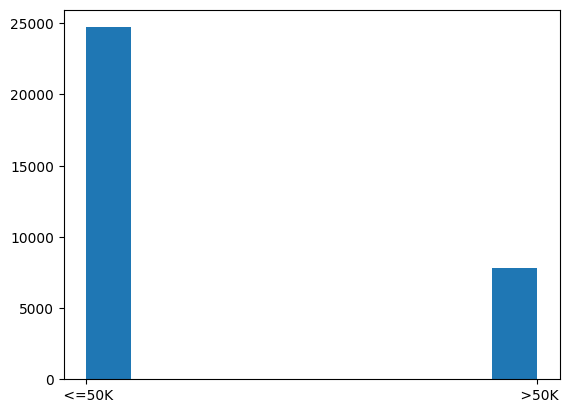

In [38]:
plt.hist(y)

In [39]:
from imblearn.over_sampling import RandomOverSampler

rdsmple = RandomOverSampler()
x_sampled , y_sampled = rdsmple.fit_resample(X ,y)

(array([24720.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 24720.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

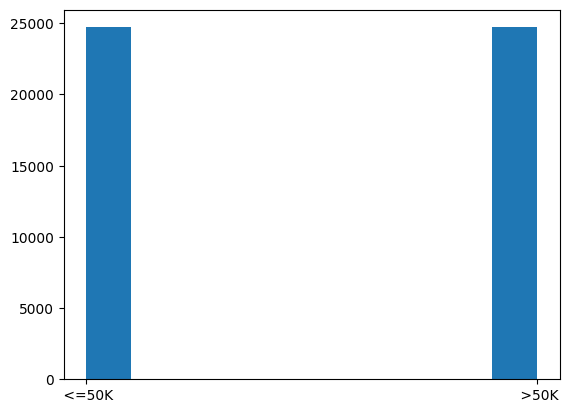

In [40]:
plt.hist(y_sampled)

In [42]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x_sampled, y_sampled, test_size=0.30, random_state=30)


In [43]:
# Transform X_train and X_test
X_train_transformed = preprocessor.fit_transform(X_train)
X_train = pd.DataFrame(X_train_transformed, columns=preprocessor.get_feature_names_out())

X_test_transformed = preprocessor.transform(X_test)
X_test = pd.DataFrame(X_test_transformed, columns=preprocessor.get_feature_names_out())

In [44]:
X_train.head()

,num_pipeline__age,num_pipeline__fnlwgt,num_pipeline__education-num,num_pipeline__capital-gain,num_pipeline__capital-loss,num_pipeline__hours-per-week,cat_pipeline__workclass,cat_pipeline__marital-status,cat_pipeline__occupation,cat_pipeline__relationship,cat_pipeline__race,cat_pipeline__sex,cat_pipeline__native-country
0,0.656090,-0.502930,0.915833,-0.201265,-0.255571,0.231046,0.059374,1.171613,0.774083,-0.119908,0.361958,-1.654011,0.284094
1,-0.197500,-0.856475,0.532685,-0.201265,-0.255571,-0.179441,0.059374,-0.319586,0.295832,-0.732785,0.361958,0.604591,-3.688090
2,0.112896,-1.008863,-0.233611,-0.201265,2.689053,-0.179441,0.059374,-1.810785,-0.660669,-0.119908,0.361958,0.604591,0.284094
3,-0.042302,-0.557249,0.149537,-0.201265,-0.255571,0.641533,0.059374,-0.319586,-0.660669,-0.732785,0.361958,0.604591,0.284094
4,2.596069,-0.189626,-0.616759,0.408810,-0.255571,-2.970754,-2.717404,-0.319586,-1.617171,-0.732785,0.361958,0.604591,0.284094


In [45]:
X_test.head()

,num_pipeline__age,num_pipeline__fnlwgt,num_pipeline__education-num,num_pipeline__capital-gain,num_pipeline__capital-loss,num_pipeline__hours-per-week,cat_pipeline__workclass,cat_pipeline__marital-status,cat_pipeline__occupation,cat_pipeline__relationship,cat_pipeline__race,cat_pipeline__sex,cat_pipeline__native-country
0,0.578491,-0.658628,-0.616759,-0.201265,-0.255571,2.283482,0.059374,-0.319586,-1.378045,-0.732785,0.361958,0.604591,0.284094
1,-0.818293,0.134237,-0.616759,-0.201265,-0.255571,-0.589928,0.059374,1.171613,0.295832,-0.119908,0.361958,-1.654011,0.284094
2,-0.119901,0.025017,-0.616759,-0.201265,-0.255571,0.477338,0.059374,1.171613,0.056707,1.718721,0.361958,0.604591,0.284094
3,0.268095,-0.616356,-0.616759,-0.201265,-0.255571,-0.179441,0.059374,-0.319586,0.056707,-0.732785,-2.117829,0.604591,0.284094
4,1.044086,-0.765435,-0.616759,-0.201265,-0.255571,-0.589928,1.447763,-0.319586,-0.899795,-0.732785,0.361958,0.604591,0.284094


(array([17238.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 17370.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

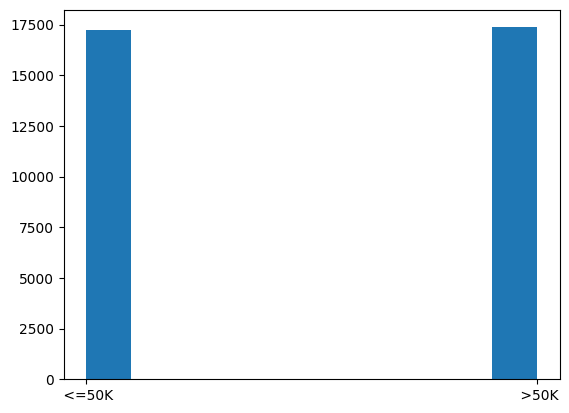

In [46]:
plt.hist(y_train)

In [47]:
## Model Training 

from sklearn.naive_bayes import GaussianNB 
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [48]:
gnb = GaussianNB()
gnb.fit(X_train , y_train)

d:\Practice program\DS\44 Income Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

In [53]:
import numpy as np
from sklearn.naive_bayes import GaussianNB 
from xgboost import XGBClassifier
from sklearn.tree import  DecisionTreeClassifier
from sklearn.ensemble import  RandomForestClassifier

from sklearn.metrics import accuracy_score , confusion_matrix , classification_report , precision_score

from sklearn.preprocessing import LabelEncoder

# Encode the target variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train.values.ravel())
y_test_encoded = label_encoder.transform(y_test.values.ravel())

# Updated evaluate_model function
def evaluate_model(true, predicted):
    ac = accuracy_score(true, predicted)
    cm = confusion_matrix(true, predicted)
    cr = classification_report(true, predicted)
    ps = precision_score(true, predicted, average='binary', pos_label=1)  # Ensure binary classification
    return ac, cm, cr, ps

models = {
    'GaussianNB': GaussianNB(),
    'XGBClassifier': XGBClassifier(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'RandomForestClassifier': RandomForestClassifier()
}

model_list = []
r2_list = []

for model_name, model in models.items():
    model.fit(X_train, y_train_encoded)  # Use encoded y_train
    y_pred = model.predict(X_test)

    ac, cm, cr, ps = evaluate_model(y_test_encoded, y_pred)  # Use encoded y_test

    print(model_name)
    model_list.append(model_name)

    print("Model Training Performance")
    print('Accuracy score:', ac)
    print('Confusion Matrix:', cm)
    print('Classification Report:', cr)
    print('Precision Score:', ps)

    r2_list.append(ps)

    print('=' * 35)
    print('\n')

GaussianNB
Model Training Performance
Accuracy score: 0.6876348435814456
Confusion Matrix: [[7007  475]
 [4158 3192]]
Classification Report:               precision    recall  f1-score   support

           0       0.63      0.94      0.75      7482
           1       0.87      0.43      0.58      7350

    accuracy                           0.69     14832
   macro avg       0.75      0.69      0.67     14832
weighted avg       0.75      0.69      0.67     14832

Precision Score: 0.8704663212435233


XGBClassifier
Model Training Performance
Accuracy score: 0.8732470334412082
Confusion Matrix: [[6262 1220]
 [ 660 6690]]
Classification Report:               precision    recall  f1-score   support

           0       0.90      0.84      0.87      7482
           1       0.85      0.91      0.88      7350

    accuracy                           0.87     14832
   macro avg       0.88      0.87      0.87     14832
weighted avg       0.88      0.87      0.87     14832

Precision Score: 0.8457